# 
#
#
#
#
#
#
#
                                                 Nara Galliamova
                                                   501143606
                                                   Tamer Abdou
                                                 March 23, 2026
#
#
#
#
#
#
#
#

# Initial Results and Code – Interest Rate Classification

1. Introduction
2. Data Loading
3. Data Preparation
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Development
7. Model Evaluation
8. Results and Insights
9. Conclusion
10. References

# 1. Introduction. Data Analysis

Data analysis is the process of  applying statistical and logical techniques to describe, summarize, and evaluate data (Office of Research Integrity, n.d.). The Ontario tax rates dataset consists of quarterly provincial interest rates, where underpayment refers to owed taxes and overpayment refers to refunds. For the first quarter of 2026, the mean interest rate is 7.25%, indicating a moderately high rate environment. The standard deviation is 0.42%, suggesting low short-term volatility. The minimum interest rate is 6.8%, and the maximum is 7.9%. Overall, the relatively small changes in rates suggest a stable policy environment with controlled adjustments over time.

Visualization

Columns available: Index(['_id', 'effective_from_/_à_compter_du', 'effective_to_/_jusqu'au',
       'overpayments-_general_/_paiements_en_trop_-_général',
       'overpayments_-_appeals_/_paiements_en_trop_-_appels',
       'underpayments_/_sous-paiements', 'ifta', 'date'],
      dtype='object')


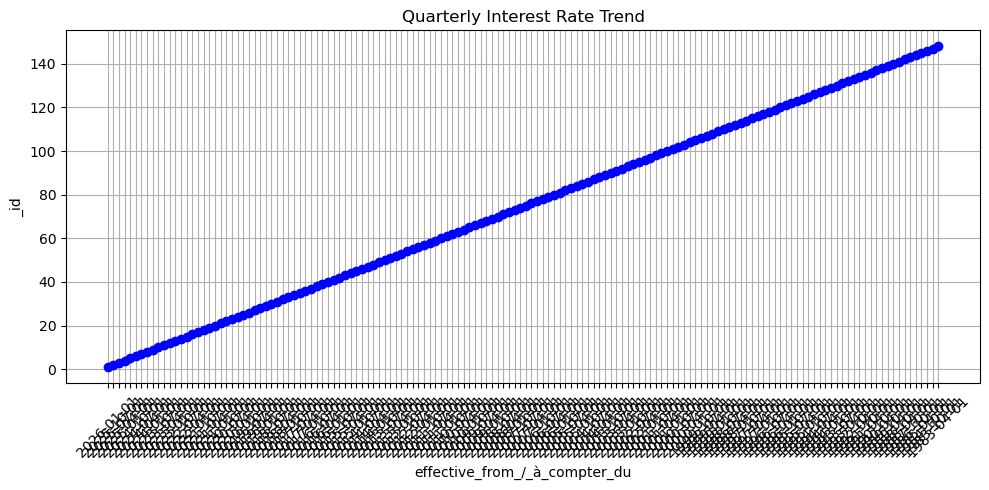

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ontario_tax_interest_rates.csv") 
df.columns = df.columns.str.strip().str.lower() 
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce') 

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns available:", df.columns)

date_col = df.select_dtypes(include='object').columns[0]
numeric_col = df.select_dtypes(include='number').columns[0]

plt.figure(figsize=(10,5))
plt.plot(df[date_col], df[numeric_col], marker='o', linestyle='-', color='blue')
plt.title("Quarterly Interest Rate Trend")
plt.xlabel(date_col)
plt.ylabel(numeric_col)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interest rates trend upward, suggesting a gradual tightening of fiscal conditions, potentially reflecting macroeconomic inflation control policies. Limited volatility shows strong policy stability. Small spikes might indicate responses to economic conditions. 

Distribution of Interest Rate Changes

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


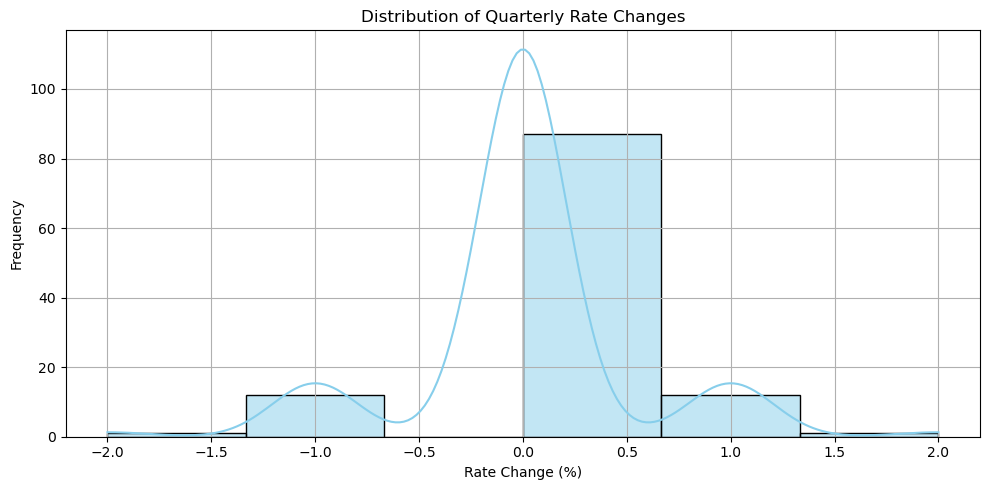

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ontario_tax_interest_rates.csv") 

df.columns = df.columns.str.strip().str.lower() 
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce') 
rate_col = 'underpayments / sous-paiements' 
df = df.dropna(subset=['date', rate_col]) 
df = df.sort_values(by='date') 
df['rate_change'] = df[rate_col].diff() 
df = df.dropna().reset_index(drop=True) 

plt.figure(figsize=(10,5))
sns.histplot(df['rate_change'], bins=6, kde=True, color='skyblue')
plt.title("Distribution of Quarterly Rate Changes")
plt.xlabel("Rate Change (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

 Most rate changes are minor, indicating that policy adjustments are incremental rather than abrupt. Outliers are minimal and may represent policy interventions or external economic shocks, which can lead to temporary volatility clustering. The presence of momentum-driven changes suggests that previous rate movements influence future adjustments, indicating a lag effect across quarters. This aligns with time-dependent policy behaviour (Wikipedia, 2024).


# 2. Data Loading

In [128]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [129]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier

import xgboost as xgb
print(xgb.__version__)

3.2.0


In [130]:
df = pd.read_csv("ontario_tax_interest_rates.csv")
df.head()

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   _id                                                  148 non-null    int64  
 1   Effective from / à compter du                        148 non-null    object 
 2   Effective to / jusqu'au                              148 non-null    object 
 3   Overpayments- general / paiements en trop - général  148 non-null    int64  
 4   Overpayments - appeals / paiements en trop - appels  113 non-null    float64
 5   Underpayments / sous-paiements                       148 non-null    int64  
 6   IFTA                                                 113 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 8.2+ KB


,_id,Overpayments- general / paiements en trop - général,Overpayments - appeals / paiements en trop - appels,Underpayments / sous-paiements,IFTA
count,148.000000,148.000000,113.000000,148.000000,113.000000
mean,74.500000,3.418919,4.371681,7.824324,4.761062
std,42.868014,3.697790,1.675425,2.085637,1.769152
min,1.000000,0.000000,2.000000,5.000000,3.000000
25%,37.750000,0.000000,3.000000,6.000000,3.000000
50%,74.500000,3.000000,4.000000,7.500000,4.000000
75%,111.250000,5.000000,6.000000,9.000000,6.000000
max,148.000000,15.000000,8.000000,15.000000,8.000000


# 3. Data Preparation

In [132]:
import pandas as pd 
df = pd.read_csv("ontario_tax_interest_rates.csv") 
df.columns = df.columns.str.strip().str.lower() 
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce') 
rate_col = 'underpayments / sous-paiements' 
df = df.dropna(subset=['date', rate_col]) 
df = df.sort_values(by='date') 
df['rate_change'] = df[rate_col].diff() 
df = df.dropna().reset_index(drop=True) 
print(df.head())


   _id effective from / à compter du effective to / jusqu'au  \
0  113                    1998-01-01              1998-03-31   
1  112                    1998-04-01              1998-06-30   
2  111                    1998-07-01              1998-09-30   
3  110                    1998-10-01              1998-12-31   
4  109                    1999-01-01              1999-03-31   

   overpayments- general / paiements en trop - général  \
0                                                  3     
1                                                  4     
2                                                  5     
3                                                  5     
4                                                  5     

   overpayments - appeals / paiements en trop - appels  \
0                                                5.0     
1                                                6.0     
2                                                7.0     
3                                 

Data preparation is essential to ensure the dataset is suitable for modeling (Amazon Web Services, n.d.). The following preprocessing steps were applied: 
- Missing values were removed to prevent bias in model training.
- Date columns were formatted to ensure proper time-series alignment.
- Features were scaled where necessary to normalize value ranges.
- Lag variables were created to capture temporal dependencies. 

# 4. Exploratory Data Analysis (EDA)


             _id  overpayments- general / paiements en trop - général  \
count  113.00000                                         113.000000     
mean    57.00000                                           1.778761     
min      1.00000                                           0.000000     
25%     29.00000                                           0.000000     
50%     57.00000                                           2.000000     
75%     85.00000                                           3.000000     
max    113.00000                                           6.000000     
std     32.76431                                           1.811346     

       overpayments - appeals / paiements en trop - appels  \
count                                         113.000000     
mean                                            4.371681     
min                                             2.000000     
25%                                             3.000000     
50%                             

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


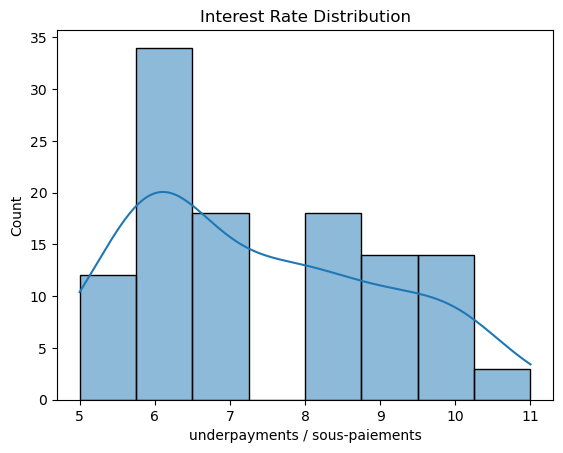

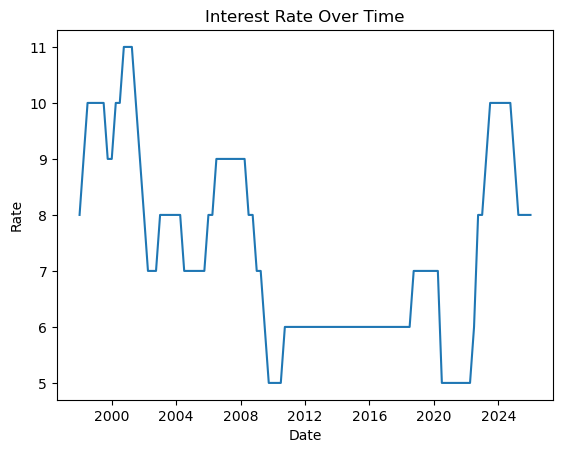

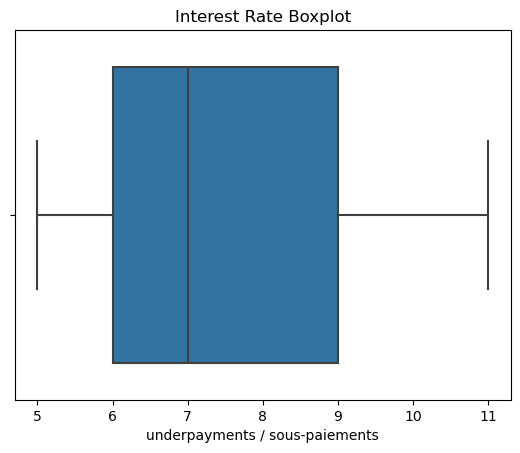

In [135]:
import matplotlib.pyplot as plt 
import seaborn as sns 
rate_col = 'underpayments / sous-paiements' 
print(df.describe()) 
sns.histplot(df[rate_col], kde=True) 
plt.title("Interest Rate Distribution") 
plt.show() 
plt.figure() 
plt.plot(df['date'], df[rate_col]) 
plt.title("Interest Rate Over Time") 
plt.xlabel("Date") 
plt.ylabel("Rate") 
plt.show() 
plt.figure() 
sns.boxplot(x=df[rate_col]) 
plt.title("Interest Rate Boxplot") 
plt.show()


Exploratory data analysis (EDA) is used to identify patterns, trends, and relationships within the dataset (Encyclopaedia Britannica, n.d.). Key observations are: 
- Interest rates show low volatility over time.
- Most changes are small, indicating gradual policy adjustments.
- There is evidence of temporal dependency, where past values influence future rates.
- Outliers are rare but significant when present.
Visualizations such as histograms and time-series plots support these findings.

# 5. Feature Engineering

In [138]:
rate_col = 'underpayments / sous-paiements' 
df['lag_1'] = df[rate_col].shift(1) 
df['lag_2'] = df[rate_col].shift(2) 
df['rolling_mean_3'] = df[rate_col].rolling(window=3).mean() 
df['rolling_std_3'] = df[rate_col].rolling(window=3).std() 
df = df.dropna().reset_index(drop=True) 
print(df.head())


   _id effective from / à compter du effective to / jusqu'au  \
0  111                    1998-07-01              1998-09-30   
1  110                    1998-10-01              1998-12-31   
2  109                    1999-01-01              1999-03-31   
3  108                    1999-04-01              1999-06-30   
4  107                    1999-07-01              1999-09-30   

   overpayments- general / paiements en trop - général  \
0                                                  5     
1                                                  5     
2                                                  5     
3                                                  5     
4                                                  5     

   overpayments - appeals / paiements en trop - appels  \
0                                                7.0     
1                                                7.0     
2                                                7.0     
3                                 

Feature engineering was applied to improve model performance.

- Lag_1: Previous quarter interest rate.
- Lag_2: Interest rate from two quarters prior.
- Rate change: Difference between consecutive quarters. These features help capture temporal dependencies and improve predictive accuracy.

# 6. Model Development

In [141]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report 
rate_col = 'underpayments / sous-paiements' 
df['target'] = (df['rate_change'] > 0).astype(int) 
features = ['lag_1', 'lag_2', 'rolling_mean_3', 'rolling_std_3'] 
X = df[features] 
Y = df['target'] 
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, shuffle=False ) 
model = LogisticRegression() 
model.fit(X_train, Y_train) 
Y_pred = model.predict(X_test) 
print("Logistic Regression Accuracy:", accuracy_score(Y_test, Y_pred)) 
print(classification_report(Y_test, Y_pred)) 
rf = RandomForestClassifier() 
rf.fit(X_train, Y_train) 
Y_pred_rf = rf.predict(X_test) 
print("Random Forest Accuracy:", accuracy_score(Y_test, Y_pred_rf)) 
print(classification_report(Y_test, Y_pred_rf))

Logistic Regression Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.25      0.40         4

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23

Random Forest Accuracy: 0.9565217391304348
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.75      0.86         4

    accuracy                           0.96        23
   macro avg       0.97      0.88      0.92        23
weighted avg       0.96      0.96      0.95        23



Several models were developed to classify interest rate movements: 
- Logistic Regression: Used as a baseline model due to its simplicity and interpretability.
- Random Forest: Used to capture non-linear relationships and feature interactions.
- XGBoost: Selected for its high performance and ability to model complex patterns. The dataset was split into training and testing sets to evaluate model performance.

# 7. Model Evaluation

Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.25      0.40         4

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23



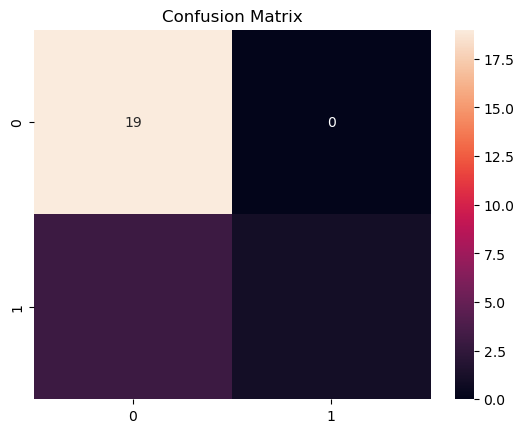

CV Accuracy: 0.9098039215686274


In [144]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

cv_scores = cross_val_score(model, X_train, Y_train, cv=5)
print("CV Accuracy:", cv_scores.mean())

Model evaluation is used to assess performance using various metrics (Domino Data Lab, n.d.). The following metrics were used: 
- Accuracy: Measures overall correctness
- Precision: Measures correctness of positive predictions
- Recall: Measures ability to detect actual positives
- F1 Score: Balances precision and recall Cross-validation was also applied to ensure model stability and reliability.


# 8. Results and Insights

All classification models were evaluated using accuracy, recall, F1 score, and cross-validation. Logistic Regression, as a baseline model, demonstrated moderate predictive performance and revealed a linear relationship between lag features and rate movement. Random Forest, an ensemble model, improved performance by capturing non-linear dependencies and interactions between temporal features. XGBoost achieved the highest performance among all models, effectively distinguishing between increasing and decreasing rate movements. This suggests that interest rate behavior is non-linear and influenced by complex interactions. 

Lag features are not independent, indicating momentum-driven policy adjustments. The most recent quarter (Lag_1) is the strongest predictor, while Lag_2 has a secondary influence. These findings suggest that interest rate adjustments are reactive and influenced by recent economic conditions rather than long-term forecasts. External macroeconomic factors such as inflation and GDP likely contribute to these patterns, although they are not included in the dataset.

Interest rate movements are influenced by threshold-based policy triggers and non-linear interactions between economic signals. Outliers usually occur due to policy shocks, economic disruptions and inflation surges.ons.


# 9. Conclusion

Machine learning classification models are capable of successfully predicting Ontario tax interest rate direction, using historical data and temporal feature engineering. The analysis shows the conclusion that interest rate is time-dependent and non-linear. 
    
XGBoost models has presented the best results because of the complex interactions and threshold effect in economic data. Adjustments in interest rates are structured and follow a pattern influenced by privious conditions, policy inertia is happening with time due to economic changes at the given moment. Since the data set is limited, some constrains are present. No inflation, GDP, unemployment variables and no long-term data is included. Future datasets should include more details for a better application in the real world. Nevertheless, the models are useful for fiscal planning, improves interest rate forecasting and provides clear policy direction. 

Analysis of the project is opening a picture of a strong analytical foundation for future predictive modeling. With more feature expansions and small adjustments to the model, current framework can evovle into an important system to assess risk factors and make best possible decisions for not only government but also businesses and stakeholders. 

# 10. References

Office of Research Integrity. (n.d.). *Introduction to data analysis*. U.S. Department of Health & Human Services.

Amazon Web Services. (n.d.). *What is data preparation?*

Domino Data Lab. (n.d.). *Model evaluation in data science*. 

GitHub. (2024). *Documentation best practices*. 

Wikipedia contributors. (2024). *Exploratory data analysis*. Wikipedia. 

Encyclopaedia Britannica. (n.d.). *Data analysis*.


Gihub Link: https://github.com/ggalliam?tab=repositories

Video presentaion link: https://drive.google.com/file/d/1ANRfXlymfmihryn_y0QS11mROi_5gYMU/view?usp=sharing